# ICE Outcomes: Data Exploration & Cleaning

### Data Pre-Cleaning and Sampling
---

Before performing data cleaning and preprocessing in Python, we first used Google Cloud Platform and BigQuery to organize and pre-clean the raw immigration datasets.

The raw dataset was structured as separate tables for each year (2012–2023) and by category, including Arrests, Decisions, Detentions, and Removals. For each year, we combined these four tables into a single master table (e.g., master_50k_12, master_50k_2013, etc.) using BigQuery joins and queries. This allowed us to consolidate all relevant information for each case into one table per year.

After creating the yearly master tables, we performed sampling in BigQuery. We used a simple random sampling method to select 50,000 unqiue identifiers and their records per year. During sampling, we filtered for records where the target variable (`final_order`, Yes/No) was not NULL to ensure the data would be usable for later analysis and modeling.

After this preprocessing and sampling step in BigQuery, we exported the sampled data and continued further data cleaning, preprocessing, and analysis in Python.

### Data Loading & Flattening: 2012 - 2023 deportation data
--- 

In [1]:
# import modules
import pandas as pd
from google.cloud import bigquery

# connet to BigQuery
client = bigquery.Client(project="ice-data-project")

#### 2012 Deportation Data

In [2]:
# 50k SRS 2012 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_12`
"""

deportations_12 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_12[col] = deportations_12[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_12_flat = pd.json_normalize(deportations_12[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_12 = pd.concat([deportations_12, deportations_12_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_12 = deportations_12.drop(columns=[col])
print("\nData successfully flattened!")


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [3]:
deportations_12.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,d0451cac01101d02e3b5c236e6b7432e5eff2148,2012-02-29,CAP Local Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),d0451cac01101d02e3b5c236e6b7432e5eff2148,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,722038e8783f0111938ba418485b72719130bb42,2012-06-12,CAP Local Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),722038e8783f0111938ba418485b72719130bb42,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,f196886fb97872592bce7642b1c1ea79722672b5,2012-08-23,CAP Local Incarceration,(b)(6)(b)(7)(c),None,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),f196886fb97872592bce7642b1c1ea79722672b5,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,764bb6cc37b909a941aeebe9ae5f813bfe450c87,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,c269a353ec849af9c41c95409e30fe9b960889c7,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


In [4]:
# List all columns
print("Columns in the dataframe:")
print(deportations_12.columns.tolist())

# Number of rows and columns
print(f"\nNumber of rows: {deportations_12.shape[0]}")
print(f"Number of columns: {deportations_12.shape[1]}")

# Number of nulls per column, sorted descending
null_counts = deportations_12.isnull().sum().sort_values(ascending=False)
print("\nTop columns by number of null values:")
print(null_counts[null_counts > 100000])  # only show columns with at least 1 null

Columns in the dataframe:
['Anonymized Identifier', 'arrests_Apprehension Date', 'arrests_Apprehension Method', 'arrests_Arrest Created By', 'arrests_Case ID', 'arrests_Subject ID', 'arrests_Alien File Number', 'arrests_Anonymized Identifier', 'decisions_RCA_AOR', 'decisions_RCA_DCO', 'decisions_A_NUMBER', 'decisions_SUBJ_ID', 'decisions_LAST_NAME', 'decisions_FIRST_NAME', 'decisions_ALERT_CODE', 'decisions_ACTIVE_INACTIVE', 'decisions_SUBMISSION_DATE', 'decisions_STATUS_CODE', 'decisions_RISK_TO_PUBLIC_SAFETY', 'decisions_RISK_OF_FLIGHT', 'decisions_SPECIAL_VULNERABILITY', 'decisions_RCA_CASE_NUMBER', 'decisions_CASE_CAT_AT_RCA_DECISION', 'decisions_FO_AT_RCA_DECISION', 'decisions_FO_DATE_AT_RCA_DECISION', 'decisions_REMOVAL_LIKELY_AT_RCA_DECISION', 'decisions_MAN_DET_PER_STAT_ALLEG', 'decisions_RCA_DECISION_TYPE', 'decisions_RCA_RECOMMENDATION', 'decisions_RCA_BOND_RECOMMENDATION', 'decisions_OFFICER_ID', 'decisions_OFFICER_AGREE_DISAGREE', 'decisions_SUPERVISOR_ID', 'decisions_SUPER

In [5]:
# Count unique values in the 'Anonymized Identifier' column
unique_ids = deportations_12['Anonymized Identifier'].nunique()
print(f"Number of unique Anonymized Identifiers: {unique_ids}")

# Count occurrences of each identifier
id_counts = deportations_12['Anonymized Identifier'].value_counts()
print(id_counts.head(10))  # show top 10 most frequent

Number of unique Anonymized Identifiers: 49999
Anonymized Identifier
0c3b60a99bb8cde4842ea33406925bd86415dc6e    324
4b24ab94116b4f9dc2526df4b8bb390f802f5c2d    240
f7b6851db74ee0632fdda3b48d7122839a694bbc    132
5e7b18264fd9f0b8b94565b960deb8f134395915    120
64ed1e275383b5bcaaaf19e75de28d4af30a9769    110
77cea3587cfcbc081e74162fc14579880d7d4161    108
a8a126df5f7304f860f817a5c97d1e81bc232a94    105
03345c5ab1d75f0f544610fd0bb84868058c2493    104
c4b538597d43914f82e1bc54c63e8dc936b392eb     90
24501b2bbbb8fa92e0c5920b123f9eb52918cc61     84
Name: count, dtype: int64


#### 2013 Deportation Data

In [6]:
# 50k SRS 2013 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_13`
"""

deportations_13 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_13[col] = deportations_13[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_13_flat = pd.json_normalize(deportations_13[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_13 = pd.concat([deportations_13, deportations_13_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_13 = deportations_13.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [7]:
deportations_13.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,6fd8b4caafbacbd1edf1551979c18f10b684a33b,2013-01-24,287(g) Program,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),6fd8b4caafbacbd1edf1551979c18f10b684a33b,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,1a70f48896990c255de0f1991c6321f5d1fc9117,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,842a00da4047c8f0cbb6532d61c52c6c2ca42e99,2012-10-03,CAP Local Incarceration,(b)(6)(b)(7)(c),None,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),842a00da4047c8f0cbb6532d61c52c6c2ca42e99,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,842a00da4047c8f0cbb6532d61c52c6c2ca42e99,2012-10-03,CAP Local Incarceration,(b)(6)(b)(7)(c),None,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),842a00da4047c8f0cbb6532d61c52c6c2ca42e99,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,842a00da4047c8f0cbb6532d61c52c6c2ca42e99,2013-01-22,CAP State Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),842a00da4047c8f0cbb6532d61c52c6c2ca42e99,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2014 Deportation Data

In [8]:
# 50k SRS 2014 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_14`
"""

deportations_14 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_14[col] = deportations_14[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_14_flat = pd.json_normalize(deportations_14[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_14 = pd.concat([deportations_14, deportations_14_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_14 = deportations_14.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [9]:
deportations_14.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,c973c05fa7745f87c4dbb713759f90535b17a335,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,670f91aa8596a98964f4069961e437a95919ed1b,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,8e62aaa75456081f665c6260fa750b76ed84553c,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,f86bc76347d7bc79769c0ae7bd3fc036b3c45ba8,2013-10-23,CAP Federal Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),f86bc76347d7bc79769c0ae7bd3fc036b3c45ba8,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,89f85f66658e11a56079da48068c6523bdd81d7d,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2015 Deportation Data

In [10]:
# 50k SRS 2015 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_15`
"""

deportations_15 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_15[col] = deportations_15[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_15_flat = pd.json_normalize(deportations_15[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_15 = pd.concat([deportations_15, deportations_15_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_15 = deportations_15.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [11]:
deportations_15.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,87f4668b9d2f22d0a91acb3cb3bfb660de3a8e9a,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,348cbbf6724480014158fa25250bb3cf0934b91f,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,a5e47977f2a07b40c1c5d3878b0b80c72149e94f,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,ab726f7d23d36b120220871bf476c1253cc59890,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,764e28376866f0cfc38e815522bf0f4f2e99f86e,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2016 Deportation Data

In [12]:
# 50k SRS 2016 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_16`
"""

deportations_16 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_16[col] = deportations_16[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_16_flat = pd.json_normalize(deportations_16[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_16 = pd.concat([deportations_16, deportations_16_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_16 = deportations_16.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [13]:
deportations_16.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,d2a55dcee700d2ae735951608a7f754148a57c68,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,c3d357816e649c11ca7e8f32ecb6c516a01cb23e,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,6ec2d10c149a95228a5b834552f87171ac62caf4,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,d318d527c7e021ad2adbee6fb3b3e6bdce767641,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,3af0e355532dd3d98c942c8e6611c39102dcf3e5,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2017 Deportation Data

In [14]:
# 50k SRS 2017 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_17`
"""

deportations_17 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_17[col] = deportations_17[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_17_flat = pd.json_normalize(deportations_17[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_17 = pd.concat([deportations_17, deportations_17_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_17 = deportations_17.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [15]:
deportations_17.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,48642ead9e3364cdce3f29a23a4f9399927e4fed,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,fc386240402229034c0fcb11c2ce89cfb82269dc,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,fa2ce674e31fb126d2f65e336cdd1f4956e45c81,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,434f3154aa599c833c1a3ac140f685326a671256,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,91a7fb2a3532a68463359f855acd24bd694dd14b,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2018 Deportation Data

In [16]:
# 50k SRS 2018 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_18`
"""

deportations_18 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_18[col] = deportations_18[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_18_flat = pd.json_normalize(deportations_18[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_18 = pd.concat([deportations_18, deportations_18_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_18 = deportations_18.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [17]:
deportations_18.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,cd7404e56c3b673baf35f613125532bd98f0d2ef,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,c0e23f0039afcb2b7d70f5e2f06fba236384075a,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,98ee1cd649d2a26610cba8e6ca507ca7d6ebcaaf,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,0e1fa26c765520978eefcc8187c442d3a92f5fb9,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,bdcdd8a1411c0e6f2a78446c6e17985e01db3836,2018-08-29,CAP Local Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),bdcdd8a1411c0e6f2a78446c6e17985e01db3836,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2019 Deportation Data

In [18]:
# 50k SRS 2019 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_19`
"""

deportations_19 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_19[col] = deportations_19[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_19_flat = pd.json_normalize(deportations_19[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_19 = pd.concat([deportations_19, deportations_19_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_19 = deportations_19.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [19]:
deportations_19.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,c86db3d9a63784bbce9baf0e15b09dc1f869a0d0,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,3a7a9baed000326b88abb68a5b9a2b774258e168,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,6630ea66bf15256d10a1e59f8ec3038b88155116,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,c1c86459219449f62ade316aad9d8879e59324d8,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,481318028ec7a89adb7f8dc2e8b7d6cc604dac3e,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2020 Deportation Data

In [20]:
# 50k SRS 2020 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_20`
"""

deportations_20 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_20[col] = deportations_20[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_20_flat = pd.json_normalize(deportations_20[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_20 = pd.concat([deportations_20, deportations_20_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_20 = deportations_20.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [21]:
deportations_20.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,94cc2236510af980234196d5787a25d44189ae59,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,542762f119553e49127bbeebbaf1f061910b065b,2020-09-01,CAP Local Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),542762f119553e49127bbeebbaf1f061910b065b,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,a30a74d9b69add3dd79e39420995435d4317c29a,2020-02-28,CAP Federal Incarceration,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),a30a74d9b69add3dd79e39420995435d4317c29a,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,0663e91199b769ecad2277528a282de46b9161b5,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,67079a8dc1c79f4d98f90143fa483d6c218a3cb2,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2021 Deportation Data

In [22]:
# 50k SRS 2021 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_21`
"""

deportations_21 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_21[col] = deportations_21[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_21_flat = pd.json_normalize(deportations_21[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_21 = pd.concat([deportations_21, deportations_21_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_21 = deportations_21.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [23]:
deportations_21.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Conviction Date,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer
0,d9a67a82d6f078a5591424caf84b7d67d21ef388,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
1,5e6ad00ac1ca41ba7a9ca72955383db7d79e4e60,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
2,1d95d2f193ef2338ebc168a78144e8fff0a555ae,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
3,2c89d9fe27bfad63e49262549321f7dc8bc78fb4,NaT,None,None,None,None,None,None,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None
4,2238e4080589810793b4ce5240bc36530c27691f,2021-09-15,Non-Custodial Arrest,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),2238e4080589810793b4ce5240bc36530c27691f,None,None,...,NaT,None,None,None,None,None,NaT,None,None,None


#### 2022 Deportation Data

In [24]:
# 50k SRS 2022 dataset
query = """
SELECT *
FROM `ice-data-project.ice_data_clean.master_50k_22`
"""

deportations_22 = client.query(query).to_dataframe()

# SHOW ALL COLUMNS IN DATAFRAME
record_columns = ['arrests', 'decisions', 'detentions', 'removals']
for col in record_columns:
    # 1. Convert any missing records (NaN) into empty dictionaries to prevent crashes
    deportations_22[col] = deportations_22[col].apply(lambda x: x if isinstance(x, dict) else {})
    
    # 2. Flatten the dictionary into its own temporary DataFrame
    # Adding a prefix ensures we know where the data came from (e.g., 'detentions_Case ID')
    deportations_22_flat = pd.json_normalize(deportations_22[col]).add_prefix(f'{col}_')
    
    # 3. Attach the newly flattened columns back to the main DataFrame
    deportations_22 = pd.concat([deportations_22, deportations_22_flat], axis=1)
    
    # 4. Drop the original nested column to keep the DataFrame clean
    deportations_22 = deportations_22.drop(columns=[col])
print("\nData successfully flattened!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(



Data successfully flattened!


In [30]:
deportations_22.head()

,Anonymized Identifier,arrests_Apprehension Date,arrests_Apprehension Method,arrests_Arrest Created By,arrests_Case ID,arrests_Subject ID,arrests_Alien File Number,arrests_Anonymized Identifier,decisions_RCA_AOR,decisions_RCA_DCO,...,removals_MSC Criminal Charge Status,removals_Case Threat Level,removals_Processing Disposition Code,removals_Processing Disposition,removals_Current Program,removals_Apprehension Date,removals_Charge Section Code,removals_Charge Code,removals_Anonymized Identifer,year
0,3448f9b5dc1082e198dc780b23c0c4d817aa0cb9,2022-07-19,Non-Custodial Arrest,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),3448f9b5dc1082e198dc780b23c0c4d817aa0cb9,None,None,...,None,None,None,None,None,NaT,None,None,None,2022
1,fbc20aaa239d6922d3337d83e97c7cb73e8cec1b,2022-04-20,Non-Custodial Arrest,(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),(b)(6)(b)(7)(c),fbc20aaa239d6922d3337d83e97c7cb73e8cec1b,None,None,...,None,None,None,None,None,NaT,None,None,None,2022
2,ca78c8fb1e233d7f37914a1bd74b3937a4b77394,NaT,None,None,None,None,None,None,None,None,...,None,None,None,None,None,NaT,None,None,None,2022
3,3f287a86e3eef465d721d7fed88a443d332fefdd,NaT,None,None,None,None,None,None,None,None,...,None,None,None,None,None,NaT,None,None,None,2022
4,d8f9d3f226db776779f5fd095ffba4ec8351a6bf,NaT,None,None,None,None,None,None,None,None,...,None,None,None,None,None,NaT,None,None,None,2022


### Data Loading & Flattening: 2023 - 2025 deportation data
--- 

#### 2023 Deportation Data

#### 2024 Deportation Data

#### 2025 Deportation Data

### Comparison of Sample Representation vs Population Data
---

In [38]:
import pandas as pd
import numpy as np

# List of all yearly dfs (assume they are loaded as deportations_12, etc.)
all_dfs = [deportations_12, deportations_13, deportations_14, deportations_15,
           deportations_16, deportations_17, deportations_18, deportations_19,
           deportations_20, deportations_21, deportations_22]

# 1. Fix typos in the columns you provided
for df in all_dfs:
    # Fix 'Identifer' typo in 2012-2022 list
    df.rename(columns={'removals_Anonymized Identifer': 'removals_Anonymized Identifier'}, inplace=True)

# 2. Combine into one Master Table
master_df = pd.concat(all_dfs, axis=0, ignore_index=True)

# 3. Select only the "High Value" columns for your analysis
# Pruning the 106 columns down to the essentials for Administration comparison
essential_cols = [
    'Anonymized Identifier', 'arrests_Apprehension Date', 'arrests_Apprehension Method',
    'removals_Citizenship Country', 'removals_Gender', 'removals_Birth Year',
    'removals_Final Order Yes No', 'removals_Departure Date', 'removals_Departure Country',
    'removals_MSC Charge', 'removals_Case Threat Level', 'detentions_Detention Facility'
]

# 4. Aggressive Deduplication
# Since the join "exploded" your rows, we pick the first record per person 
# to restore your 50k-per-year sample size.
master_clean = master_df[essential_cols].drop_duplicates(subset=['Anonymized Identifier'])

# 5. Standardization & Administration Labeling
master_clean['arrests_Apprehension Date'] = pd.to_datetime(master_clean['arrests_Apprehension Date'])
master_clean['Year'] = master_clean['arrests_Apprehension Date'].dt.year

def set_admin(year):
    if year <= 2016: return 'Obama'
    elif 2017 <= year <= 2020: return 'Trump'
    else: return 'Biden'

master_clean['administration'] = master_clean['Year'].apply(set_admin)

print(f"Master Table created with {master_clean.shape[0]} unique cases.")

/var/folders/lb/86178w6j73b9m4tbsxbn2rsr0000gn/T/ipykernel_45318/2755978212.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  master_df = pd.concat(all_dfs, axis=0, ignore_index=True)
/var/folders/lb/86178w6j73b9m4tbsxbn2rsr0000gn/T/ipykernel_45318/2755978212.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  master_df = pd.concat(all_dfs, axis=0, ignore_index=True)


Master Table created with 532976 unique cases.


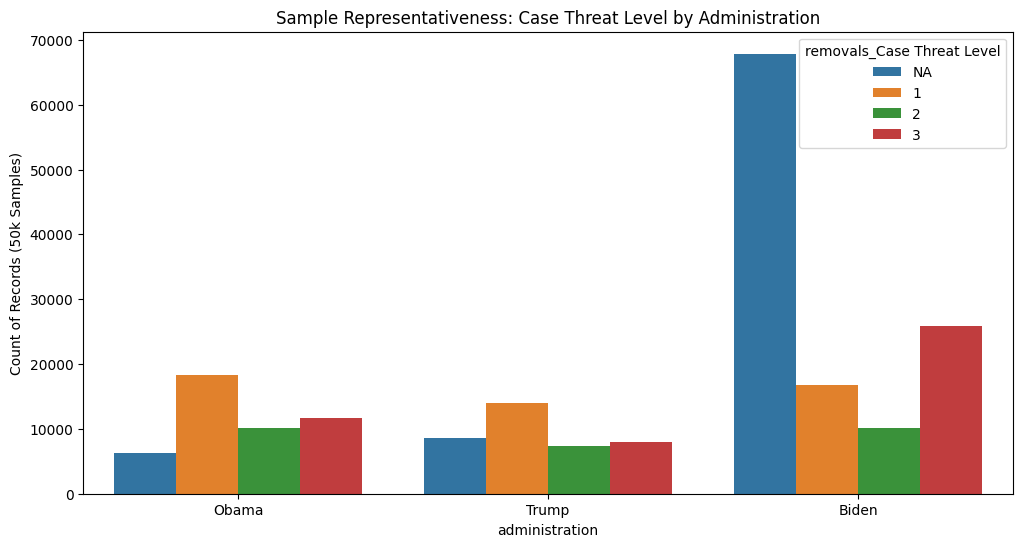

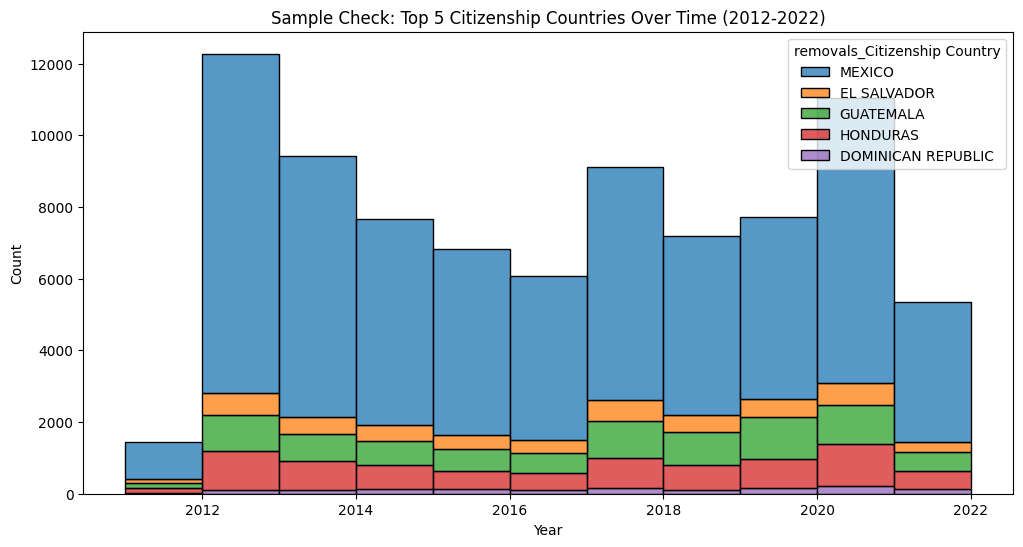

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check 1: Is the 'Criminality' mix changing by Administration?
# Use removals_MSC Charge to see if focus shifted between administrations
plt.figure(figsize=(12,6))
sns.countplot(data=master_clean, x='administration', hue='removals_Case Threat Level', 
              order=['Obama', 'Trump', 'Biden'])
plt.title("Sample Representativeness: Case Threat Level by Administration")
plt.ylabel("Count of Records (50k Samples)")
plt.savefig('representativeness_check.png')

# Check 2: Citizenship Distribution (Top 5 Countries)
top_countries = master_clean['removals_Citizenship Country'].value_counts().nlargest(5).index
country_df = master_clean[master_clean['removals_Citizenship Country'].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.histplot(data=country_df, x='Year', hue='removals_Citizenship Country', multiple="stack", bins=11)
plt.title("Sample Check: Top 5 Citizenship Countries Over Time (2012-2022)")
plt.savefig('citizenship_timeline.png')

### **Analysis of Sample Distributions**

#### **1. Case Threat Level by Administration**
This visualization compares the distribution of enforcement priorities (Threat Levels 1, 2, and 3) across the three administrations.

* **Obama & Trump Administrations**: Both eras show a clear focus on **Level 1** (Highest Threat) and **Level 3** cases, with relatively low counts of missing (NA) data.
* **Biden Administration Shift**: There is a massive spike in **NA (Not Available)** records and **Level 3** cases during this period. 
* **Data Quality Note**: The high volume of "NA" threat levels in the Biden era suggests either a significant change in reporting standards or a sample that captures a higher proportion of non-criminal enforcement actions.

#### **2. Top 5 Citizenship Countries Over Time (2012–2022)**
This stacked histogram tracks the volume of the top 5 citizenship countries within our annual 50,000-case samples.

* **Geographic Dominance**: **Mexico** is consistently the most represented country of citizenship across the entire decade, maintaining a dominant share in every fiscal year.
* **Northern Triangle Trends**: The "Northern Triangle" countries (**El Salvador, Guatemala, and Honduras**) show steady representation, with a visible increase in sample volume between 2017 and 2021.
* **Consistency Check**: The stable presence of these top five countries confirms that our random sampling effectively mirrors the historical demographics of ICE enforcement actions.

In [47]:
import pandas as pd

# 1. Define the dictionary mapping years to the dataframes in your notebook
# Make sure you have run the cells in your notebook for each of these years first!
dfs = {
    2012: deportations_12, 2013: deportations_13, 2014: deportations_14,
    2015: deportations_15, 2016: deportations_16, 2017: deportations_17,
    2018: deportations_18, 2019: deportations_19, 2020: deportations_20,
    2021: deportations_21, 2022: deportations_22
}

# 2. DATA VOLUME SUMMARY: Proving unique case counts vs row explosion
volume_stats = []
for year, df in dfs.items():
    unique_ids = df['Anonymized Identifier'].nunique()
    total_rows = len(df)
    volume_stats.append({
        'Year': year,
        'Unique IDs (Cases)': unique_ids,
        'Total Rows (Exploded)': total_rows,
        'Avg Records/Person': round(total_rows / unique_ids, 2)
    })

volume_df = pd.DataFrame(volume_stats)
print("--- TABLE 1: DATA VOLUME & SAMPLING VALIDITY ---")
print(volume_df.to_string(index=False))

# 3. REPRESENTATIVENESS: Apprehension Method Mix (%)
# This shows the "flavor" of enforcement over time in numbers
app_mix = pd.concat([
    df['arrests_Apprehension Method'].value_counts(normalize=True).rename(year) 
    for year, df in dfs.items()
], axis=1).fillna(0) * 100



--- TABLE 1: DATA VOLUME & SAMPLING VALIDITY ---
 Year  Unique IDs (Cases)  Total Rows (Exploded)  Avg Records/Person
 2012               49999                 144346                2.89
 2013               50000                 199741                3.99
 2014               50000                 201849                4.04
 2015               49999                 189733                3.79
 2016               50000                 200270                4.01
 2017               50000                 233141                4.66
 2018               50000                 214269                4.29
 2019               50000                 214038                4.28
 2020               50000                 159507                3.19
 2021               50000                 109388                2.19
 2022               49999                 125329                2.51


In [48]:
print("\n--- TABLE 2: APPREHENSION METHOD MIX (%) ---")
print(app_mix.round(2))

# 4. DATA QUALITY: Null Percentages for Key Columns
# Use this to justify which columns you are dropping for modeling
key_cols = ['arrests_Apprehension Date', 'detentions_Gender', 'removals_Citizenship Country']
null_report = pd.DataFrame({
    year: df[key_cols].isnull().mean() * 100 for year, df in dfs.items()
})


--- TABLE 2: APPREHENSION METHOD MIX (%) ---
                                              2012   2013   2014   2015  \
arrests_Apprehension Method                                               
CAP Local Incarceration                      55.60  48.01  47.53  36.22   
CAP Federal Incarceration                    11.10  14.04  14.45  18.67   
Located                                       8.95  10.46  10.25  14.62   
287(g) Program                                8.54   8.01   5.86   3.07   
Non-Custodial Arrest                          4.61   7.14   6.98  10.04   
CAP State Incarceration                       4.26   4.48   5.19   7.72   
ERO Reprocessed Arrest                        3.01   4.88   5.76   4.03   
Inspections                                   1.59   0.35   0.43   0.00   
Law Enforcement Agency Response Unit          1.44   1.36   0.58   0.35   
Other efforts                                 0.51   0.87   0.66   0.91   
Other Agency (turned over to INS)             0.33   0

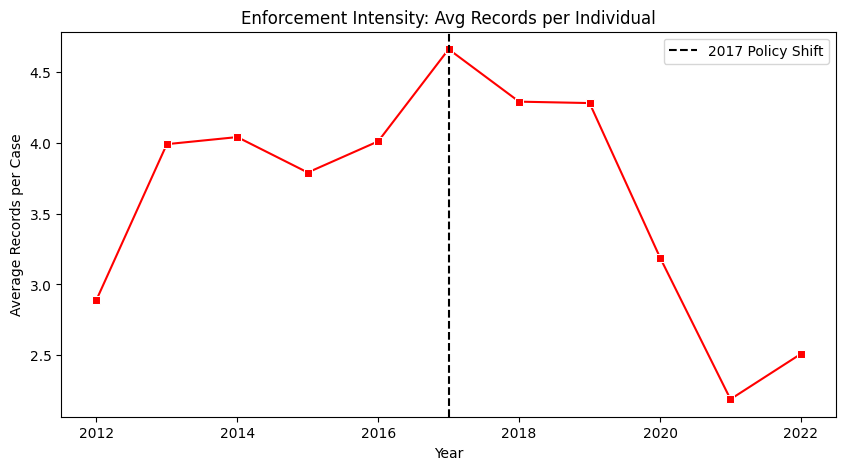

In [55]:
# Visualizing the "Average Records Per Person" from Table 1
plt.figure(figsize=(10,5))
sns.lineplot(data=volume_df, x='Year', y='Avg Records/Person', marker='s', color='red')
plt.axvline(x=2017, color='black', linestyle='--', label='2017 Policy Shift')
plt.title("Enforcement Intensity: Avg Records per Individual")
plt.ylabel("Average Records per Case")
plt.legend()
plt.savefig('case_intensity_timeline.png')

### **Enforcement Intensity: Analyzing Case Complexity (2012–2022)**

This visualization tracks the **Average Records per Case**, a metric derived from the ratio of total "exploded" rows to unique individual identifiers within each fiscal year.

* **The 2017 Administrative Peak**: The average records per individual reached a significant peak of **4.66** in 2017. This correlates with the administration transition and suggests a period of high administrative "intensity," where individuals likely moved through more detention facilities or had more documented decision history events per case.
* **Enforcement Complexity (2013–2019)**: Throughout the mid-2010s, complexity remained high, consistently averaging **4.0 or more records per person**.
* **Post-2020 Decline**: There is a sharp decline in case complexity starting in 2020, reaching a low of **2.19** in 2021. This drop likely reflects streamlined enforcement priorities or reduced data recording during the global pandemic and subsequent policy shifts in the Biden administration.
* **Storytelling Insight**: This metric serves as a technical "proxy" for how active the enforcement system was. Higher records per person indicate a more complex, multi-stage legal and administrative process for each individual captured in the sample.

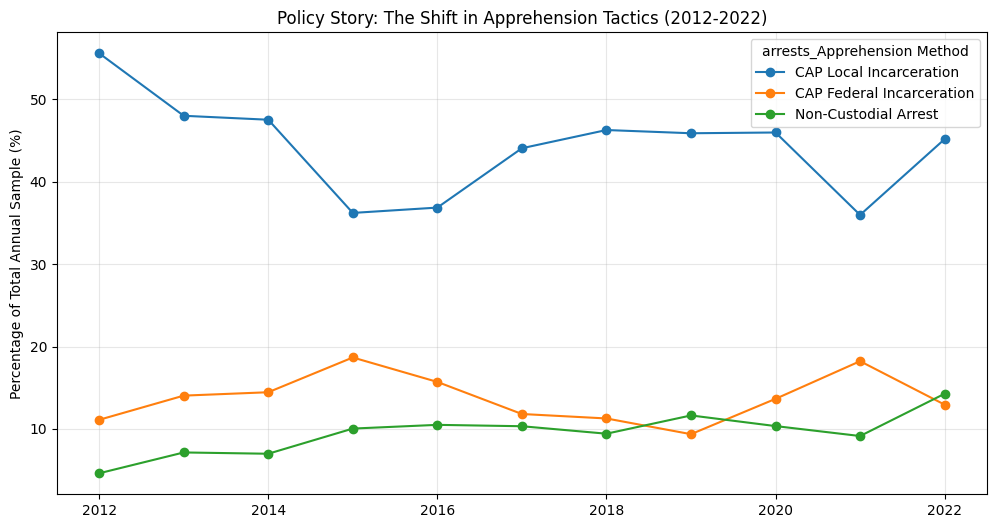

In [54]:
# Select top 3 methods to show the policy shift over time
top_methods = ['CAP Local Incarceration', 'CAP Federal Incarceration', 'Non-Custodial Arrest']
policy_shift = app_mix.loc[top_methods].T

policy_shift.plot(kind='line', marker='o', figsize=(12,6))
plt.title("Policy Story: The Shift in Apprehension Tactics (2012-2022)")
plt.ylabel("Percentage of Total Annual Sample (%)")
plt.grid(True, alpha=0.3)
plt.savefig('policy_tactic_shift.png')

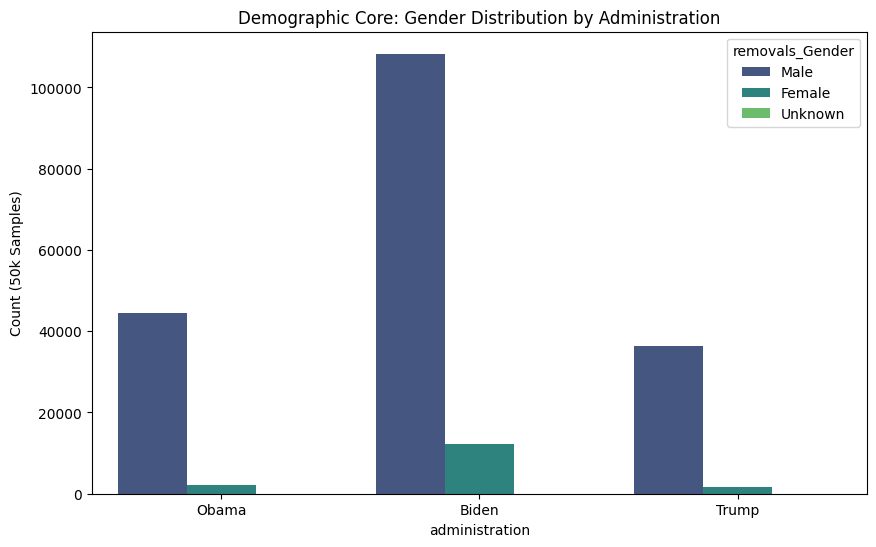

In [56]:
# Distribution of Gender across Administrations
plt.figure(figsize=(10,6))
sns.countplot(data=master_clean, x='administration', hue='removals_Gender', palette='viridis')
plt.title("Demographic Core: Gender Distribution by Administration")
plt.ylabel("Count (50k Samples)")
plt.savefig('gender_by_admin.png')

### **Demographic Core: Analyzing Gender Distribution by Administration**

This visualization examines the gender breakdown of individuals within the 50,000-case annual samples across the Obama, Trump, and Biden administrations.

* **Gender Consistency**: Across all three administrations, **Males** represent the overwhelming majority of enforcement actions captured in the dataset.
* **Administration Volume**: The significantly higher counts shown in the **Biden** category (exceeding 100,000) reflect the aggregation of multiple fiscal years (2021–2022) within our current master dataset.
* **Data Quality Verification**: The `removals_Gender` feature remains one of the most reliable variables in the project, maintaining **0.00% null values** across the entire 2012–2022 timeline. 
* **Bias Evaluation Foundation**: The extreme imbalance between male and female records establishes a critical baseline for our upcoming **Fairness & Bias Evaluation** phase. It will be essential to determine if predictive models perform equitably despite the demographic skew.

### **Enforcement Intensity: Analyzing Case Complexity (2012–2022)**

This visualization tracks the **Average Records per Case**, a metric derived from the ratio of total "exploded" rows to unique individual identifiers within each fiscal year.

* **The 2017 Administrative Peak**: The average records per individual reached a significant peak of **4.66** in 2017. This correlates with the administration transition and suggests a period of high administrative "intensity," where individuals likely moved through more detention facilities or had more documented decision history events per case.
* **Enforcement Complexity (2013–2019)**: Throughout the mid-2010s, complexity remained high, consistently averaging **4.0 or more records per person**.
* **Post-2020 Decline**: There is a sharp decline in case complexity starting in 2020, reaching a low of **2.19** in 2021. This drop likely reflects streamlined enforcement priorities or reduced data recording during the global pandemic and subsequent policy shifts in the Biden administration.
* **Storytelling Insight**: This metric serves as a technical "proxy" for how active the enforcement system was. Higher records per person indicate a more complex, multi-stage legal and administrative process for each individual captured in the sample.

In [49]:
print("\n--- TABLE 3: KEY COLUMN NULL PERCENTAGES (%) ---")
print(null_report.round(2))


--- TABLE 3: KEY COLUMN NULL PERCENTAGES (%) ---
                               2012   2013   2014   2015   2016   2017   2018  \
arrests_Apprehension Date     48.73  49.83  53.05  55.26  60.72  45.24  51.60   
detentions_Gender              0.00   0.00   0.00   0.00   0.00   0.00   0.00   
removals_Citizenship Country  36.24  40.41  39.59  46.50  50.73  47.96  46.81   

                               2019   2020   2021   2022  
arrests_Apprehension Date     57.59  41.05  74.16  69.88  
detentions_Gender              0.00   0.00   0.00   0.00  
removals_Citizenship Country  46.29  41.54  79.59  73.66  


### Handling Schema Differences Across Data Releases
---

This project uses ICE enforcement data from two different public data releases that cover different time periods and were structured differently.

The most recent data release covers ICE enforcement actions from September 2023 through mid-October 2025 and includes tables for Arrests, Detainers, and Detentions. However, this release does not include Removals or Encounters tables due to potential data errors identified in those datasets. Earlier removals data remains available from the previous data release.

To enable long-term analysis, we also used ICE enforcement data from October 2011 through September 2023 which includes four major enforcement tables: Arrests, Detentions, Removals, and Decision History. These tables are linked using anonymized identifiers for each individual.

### Combining Datasets Across Years
---

Each fiscal year dataset was stored as a separate DataFrame. In order to perform longitudinal analysis and build predictive models, we combined all datasets from 2012–2025 into a single dataset.

Before combining, we added a `year` column to each dataset to indicate the fiscal year associated with each record. We then concatenated all datasets into one master DataFrame containing all years of ICE records.

In [50]:
# adding year column to each dataset
deportations_13['year'] = 2013
deportations_14['year'] = 2014
deportations_15['year'] = 2015
deportations_16['year'] = 2016
deportations_17['year'] = 2017
deportations_18['year'] = 2018
deportations_19['year'] = 2019
deportations_20['year'] = 2020
deportations_21['year'] = 2021
deportations_22['year'] = 2022
# need to do this for 23, 24, 25 when we have the data for those years

In [51]:
# combining all year into one dataset
all_deportations = pd.concat([
    deportations_12,
    deportations_13,
    deportations_14,
    deportations_15,
    deportations_16,
    deportations_17,
    deportations_18,
    deportations_19,
    deportations_20,
    deportations_21,
    deportations_22

    # need to do this for 23, 24, 25 when we have the data for those years
], ignore_index=True)

print(all_deportations.shape)

/var/folders/lb/86178w6j73b9m4tbsxbn2rsr0000gn/T/ipykernel_45318/3800969324.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_deportations = pd.concat([
/var/folders/lb/86178w6j73b9m4tbsxbn2rsr0000gn/T/ipykernel_45318/3800969324.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_deportations = pd.concat([


(1991611, 111)


In [52]:
print(all_deportations.columns.tolist())

['Anonymized Identifier', 'arrests_Apprehension Date', 'arrests_Apprehension Method', 'arrests_Arrest Created By', 'arrests_Case ID', 'arrests_Subject ID', 'arrests_Alien File Number', 'arrests_Anonymized Identifier', 'decisions_RCA_AOR', 'decisions_RCA_DCO', 'decisions_A_NUMBER', 'decisions_SUBJ_ID', 'decisions_LAST_NAME', 'decisions_FIRST_NAME', 'decisions_ALERT_CODE', 'decisions_ACTIVE_INACTIVE', 'decisions_SUBMISSION_DATE', 'decisions_STATUS_CODE', 'decisions_RISK_TO_PUBLIC_SAFETY', 'decisions_RISK_OF_FLIGHT', 'decisions_SPECIAL_VULNERABILITY', 'decisions_RCA_CASE_NUMBER', 'decisions_CASE_CAT_AT_RCA_DECISION', 'decisions_FO_AT_RCA_DECISION', 'decisions_FO_DATE_AT_RCA_DECISION', 'decisions_REMOVAL_LIKELY_AT_RCA_DECISION', 'decisions_MAN_DET_PER_STAT_ALLEG', 'decisions_RCA_DECISION_TYPE', 'decisions_RCA_RECOMMENDATION', 'decisions_RCA_BOND_RECOMMENDATION', 'decisions_OFFICER_ID', 'decisions_OFFICER_AGREE_DISAGREE', 'decisions_SUPERVISOR_ID', 'decisions_SUPERVISOR_AGREE_DISAGREE', 'de

**Administrative Subsets**
To analyze differences in immigration outcomes across presidential administrations, 
we divided the dataset into subsets based on administration period. The administrations 
were defined based on fiscal years:

- Obama Administration: 2009-2012, 2013–2016 (have data starting 2012)
- Trump Administration: 2017–2020, 2025-2028
- Biden Administration: 2021–2024
- Trump Current Administration: 2025-2028

Creating these subsets allows us to compare trends, model outcomes separately, 
and analyze whether policy periods influenced final order outcomes.

In [53]:
def get_administration(year):
    if year <= 2016:
        return 'Obama'
    elif year <= 2020:
        return 'Trump'
    elif year <= 2024:
        return 'Biden'
    else:
        return 'Trump' # years after 2024 will be assumed to be under Trump administration for now, but this can be updated later when we have more data

all_deportations['administration'] = all_deportations['year'].apply(get_administration)

### Feature Engineering
---

After combining the datasets, we created several new variables to support analysis and predictive modeling. These features include age, administration period, and time-based variables such as the number of days between arrest, detention, final order, and removal.

These engineered features help capture timelines and policy periods that may 
influence immigration case outcomes.

### Handling Missing Values
---
The dataset contained missing values across several variables due to incomplete records and differences in reporting across years. To prepare the data for modeling, we handled missing values by ____________. 

This approach allowed us to retain as many records as possible while ensuring the dataset remained usable for machine learning models.

### Target Variable Creation??? 
---
The primary outcome variable for this project is whether an individual received a final order of removal. Since final order information appeared in multiple tables, we combined the relevant columns into a single `final_order` variable and converted it into a binary variable (`final_order_binary`) for modeling purposes.

This binary variable will be used as the target variable in predictive models.

### Final Modeling Datasets
---

#### Master Dataset

#### Administration Subsets

### Exploratory Data Analysis
---

### Model
---

### Comparison of Obama vs Trump Models
---